In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import os

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

# Define the base results directory
results_base_dir = "/data/projects/punim0478/setiawand/bible-nmt/results"

# Function to automatically load all glossary metrics JSON files
def load_gemini_glossary_results(base_dir):
    results_data = {}
    
    # Find all gemini-2.5-flash-*-dhao directories
    gemini_dirs = glob.glob(os.path.join(base_dir, "gemini-2.5-flash-*-dhao"))
    
    for gemini_dir in sorted(gemini_dirs):
        # Extract variant name from directory (e.g., "engBBE" from "gemini-2.5-flash-engBBE-dhao")
        dir_name = os.path.basename(gemini_dir)
        variant = dir_name.replace("gemini-2.5-flash-", "").replace("-dhao", "")
        
        print(f"Processing variant: {variant}")
        
        # Find all glossary subdirectories (glossary and glossary_full)
        glossary_dirs = glob.glob(os.path.join(gemini_dir, "glossary*"))
        
        for glossary_dir in sorted(glossary_dirs):
            glossary_config = os.path.basename(glossary_dir)
            
            # Look for the metrics JSON file
            json_pattern = os.path.join(glossary_dir, "*_metrics.json")
            json_files = glob.glob(json_pattern)
            
            if json_files:
                json_file = json_files[0]  # Take the first match
                print(f"  Loading: {glossary_config} -> {os.path.basename(json_file)}")
                
                try:
                    with open(json_file, 'r') as f:
                        data = json.load(f)
                    
                    # Create key for this configuration
                    config_key = f"{variant}-{glossary_config}"
                    results_data[config_key] = data
                    
                except Exception as e:
                    print(f"    Error loading {json_file}: {e}")
            else:
                print(f"    No metrics JSON found in {glossary_dir}")
    
    return results_data

# Load all the data automatically
print("🔍 Automatically discovering and loading glossary JSON files...")
print("=" * 60)

results_data = load_gemini_glossary_results(results_base_dir)

print("=" * 60)
print("✅ Data loaded successfully!")
print(f"📊 Total configurations analyzed: {len(results_data)}")

if results_data:
    variants = list(set([key.split('-')[0] for key in results_data.keys()]))
    glossary_configs = list(set(['-'.join(key.split('-')[1:]) for key in results_data.keys()]))
    
    print(f"🧬 Variants found: {variants}")
    print(f"⚙️  Glossary configs: {glossary_configs}")
    
    # Show a sample of the loaded data
    print(f"\n📋 Sample configuration: {list(results_data.keys())[0]}")
    sample_data = results_data[list(results_data.keys())[0]]
    print(f"   Metrics available: {list(sample_data.keys())}")
else:
    print("❌ No data found! Please check the directory structure.")


🔍 Automatically discovering and loading glossary JSON files...
Processing variant: engBBE
  Loading: glossary -> gemini-2.5-flash_aligned-eng-engBBE-ot_eng_nfa_metrics.json
  Loading: glossary_full -> gemini-2.5-flash_aligned-eng-engBBE-ot_eng_nfa_metrics.json
Processing variant: engwyc2017
  Loading: glossary -> gemini-2.5-flash_aligned-eng-engwyc2017-ot_eng_nfa_metrics.json
  Loading: glossary_full -> gemini-2.5-flash_aligned-eng-engwyc2017-ot_eng_nfa_metrics.json
Processing variant: engwyc2018
  Loading: glossary -> gemini-2.5-flash_aligned-eng-engwyc2018-ot_eng_nfa_metrics.json
  Loading: glossary_full -> gemini-2.5-flash_aligned-eng-engwyc2018-ot_eng_nfa_metrics.json
Processing variant: webp
  Loading: glossary -> gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json
  Loading: glossary_full -> gemini-2.5-flash_aligned-eng-engwebp-ot_eng_nfa_metrics.json
✅ Data loaded successfully!
📊 Total configurations analyzed: 8
🧬 Variants found: ['engBBE', 'webp', 'engwyc2018', 'engwyc

In [2]:
# Convert data to DataFrame for easier analysis
df_rows = []
for config_name, metrics in results_data.items():
    parts = config_name.split('-')
    variant = parts[0]
    glossary_config = '-'.join(parts[1:])
    
    # Add original metrics
    row_orig = {'variant': variant, 'glossary_config': glossary_config, 'metric_type': 'original'}
    row_orig.update(metrics['original_mt_metrics'])
    df_rows.append(row_orig)
    
    # Add post-edited metrics  
    row_pe = {'variant': variant, 'glossary_config': glossary_config, 'metric_type': 'post_edited'}
    row_pe.update(metrics['post_edited_metrics'])
    df_rows.append(row_pe)
    
    # Add improvement metrics
    row_imp = {'variant': variant, 'glossary_config': glossary_config, 'metric_type': 'improvement'}
    row_imp.update(metrics['improvements'])
    df_rows.append(row_imp)

df = pd.DataFrame(df_rows)

# Create separate DataFrames for different analyses
df_post_edited = df[df['metric_type'] == 'post_edited'].copy()
df_improvements = df[df['metric_type'] == 'improvement'].copy()

print("DataFrame shapes:")
print(f"Full data: {df.shape}")
print(f"Post-edited only: {df_post_edited.shape}")
print(f"Improvements only: {df_improvements.shape}")
print("\nAvailable variants:", df['variant'].unique())
print("Glossary configurations:", df['glossary_config'].unique())


DataFrame shapes:
Full data: (24, 9)
Post-edited only: (8, 9)
Improvements only: (8, 9)

Available variants: ['engBBE' 'engwyc2017' 'engwyc2018' 'webp']
Glossary configurations: ['glossary' 'glossary_full']


In [3]:
# ANALYSIS: First find best glossary config for each version, then compare
print("=" * 80)
print("STEP 1: FIND BEST GLOSSARY CONFIGURATION FOR EACH BIBLE VERSION")
print("=" * 80)

# Focus on the requested metrics only
metrics_to_analyze = ['sacrebleu', 'spbleu', 'chrf3', 'chrf++']
print(f"📊 Analyzing metrics: {metrics_to_analyze}")

print("\n🔍 Finding best glossary configuration for each Bible version...")
print("-" * 60)

best_configs_by_version = {}

for variant in df_improvements['variant'].unique():
    print(f"\n📖 {variant.upper()}:")
    
    variant_data = df_improvements[df_improvements['variant'] == variant]
    
    # Calculate average improvement across the 4 metrics for each glossary config
    config_scores = {}
    for glossary_config in variant_data['glossary_config'].unique():
        config_data = variant_data[variant_data['glossary_config'] == glossary_config]
        avg_improvement = config_data[metrics_to_analyze].mean().mean()
        config_scores[glossary_config] = avg_improvement
        
        print(f"  {glossary_config:15}: {avg_improvement:7.4f} (avg improvement)")
    
    # Find the best glossary config for this variant
    best_config = max(config_scores.items(), key=lambda x: x[1])
    best_configs_by_version[variant] = {
        'glossary_config': best_config[0],
        'avg_improvement': best_config[1]
    }
    
    print(f"  🏆 WINNER: {best_config[0]} ({best_config[1]:.4f})")

print("\n" + "=" * 80)
print("STEP 2: COMPARE BEST CONFIGURATIONS ACROSS BIBLE VERSIONS")
print("=" * 80)

# Create a filtered dataset with only the best configurations
best_config_data = []

for variant in best_configs_by_version.keys():
    best_glossary_config = best_configs_by_version[variant]['glossary_config']
    
    # Get the data for this best configuration
    config_key = f"{variant}-{best_glossary_config}"
    if config_key in results_data:
        best_config_data.append({
            'variant': variant,
            'glossary_config': best_glossary_config,
            'config_key': config_key,
            'data': results_data[config_key]
        })

print(f"\n📊 Comparing {len(best_config_data)} best configurations:")
for config in best_config_data:
    print(f"  • {config['variant'].upper()}: {config['glossary_config']}")

# Create comparison DataFrames with only the best configurations
best_pe_comparison = []
best_imp_comparison = []

for config in best_config_data:
    variant = config['variant']
    glossary_config = config['glossary_config']
    data = config['data']
    
    # Post-edited metrics
    pe_row = {'variant': variant, 'glossary_config': glossary_config}
    pe_row.update(data['post_edited_metrics'])
    best_pe_comparison.append(pe_row)
    
    # Improvement metrics  
    imp_row = {'variant': variant, 'glossary_config': glossary_config}
    imp_row.update(data['improvements'])
    best_imp_comparison.append(imp_row)

best_pe_df = pd.DataFrame(best_pe_comparison)
best_imp_df = pd.DataFrame(best_imp_comparison)

print("\n1. POST-EDITED PERFORMANCE (Best configs only):")
print("-" * 50)

for _, row in best_pe_df.iterrows():
    print(f"\n{row['variant'].upper()} ({row['glossary_config']}):")
    for metric in metrics_to_analyze:
        print(f"  {metric:10}: {row[metric]:7.4f}")

print("\n2. IMPROVEMENTS (Best configs only):")
print("-" * 40)

for _, row in best_imp_df.iterrows():
    print(f"\n{row['variant'].upper()} ({row['glossary_config']}):")
    for metric in metrics_to_analyze:
        print(f"  {metric:10}: +{row[metric]:6.4f}")

# Rank the best configurations
print("\n3. FINAL RANKING (Best config from each version):")
print("-" * 55)

# Rank by post-edited performance
pe_rankings = {}
for metric in metrics_to_analyze:
    ranked = best_pe_df.sort_values(metric, ascending=False)
    for i, (_, row) in enumerate(ranked.iterrows()):
        variant = row['variant']
        if variant not in pe_rankings:
            pe_rankings[variant] = []
        pe_rankings[variant].append(i + 1)

avg_pe_rankings = {variant: np.mean(ranks) for variant, ranks in pe_rankings.items()}
sorted_pe_rankings = sorted(avg_pe_rankings.items(), key=lambda x: x[1])

print("\nA. BY POST-EDITED PERFORMANCE:")
for i, (variant, avg_rank) in enumerate(sorted_pe_rankings):
    config = best_configs_by_version[variant]['glossary_config']
    print(f"  {i+1}. {variant.upper():12} ({config:15}) - Avg rank: {avg_rank:.2f}")

# Rank by improvement
imp_rankings = {}
for metric in metrics_to_analyze:
    ranked = best_imp_df.sort_values(metric, ascending=False)
    for i, (_, row) in enumerate(ranked.iterrows()):
        variant = row['variant']
        if variant not in imp_rankings:
            imp_rankings[variant] = []
        imp_rankings[variant].append(i + 1)

avg_imp_rankings = {variant: np.mean(ranks) for variant, ranks in imp_rankings.items()}
sorted_imp_rankings = sorted(avg_imp_rankings.items(), key=lambda x: x[1])

print("\nB. BY IMPROVEMENT:")
for i, (variant, avg_rank) in enumerate(sorted_imp_rankings):
    config = best_configs_by_version[variant]['glossary_config']
    print(f"  {i+1}. {variant.upper():12} ({config:15}) - Avg rank: {avg_rank:.2f}")

print(f"\n🏆 OVERALL WINNER (Performance): {sorted_pe_rankings[0][0].upper()}")
print(f"🚀 BEST IMPROVER: {sorted_imp_rankings[0][0].upper()}")


STEP 1: FIND BEST GLOSSARY CONFIGURATION FOR EACH BIBLE VERSION
📊 Analyzing metrics: ['sacrebleu', 'spbleu', 'chrf3', 'chrf++']

🔍 Finding best glossary configuration for each Bible version...
------------------------------------------------------------

📖 ENGBBE:
  glossary       :  3.6576 (avg improvement)
  glossary_full  :  5.1335 (avg improvement)
  🏆 WINNER: glossary_full (5.1335)

📖 ENGWYC2017:
  glossary       :  3.3463 (avg improvement)
  glossary_full  :  4.9565 (avg improvement)
  🏆 WINNER: glossary_full (4.9565)

📖 ENGWYC2018:
  glossary       :  3.8314 (avg improvement)
  glossary_full  :  5.1976 (avg improvement)
  🏆 WINNER: glossary_full (5.1976)

📖 WEBP:
  glossary       :  3.0965 (avg improvement)
  glossary_full  :  4.5678 (avg improvement)
  🏆 WINNER: glossary_full (4.5678)

STEP 2: COMPARE BEST CONFIGURATIONS ACROSS BIBLE VERSIONS

📊 Comparing 4 best configurations:
  • ENGBBE: glossary_full
  • ENGWYC2017: glossary_full
  • ENGWYC2018: glossary_full
  • WEBP: gloss


STEP 3: VISUALIZATIONS (Best Configurations Only)


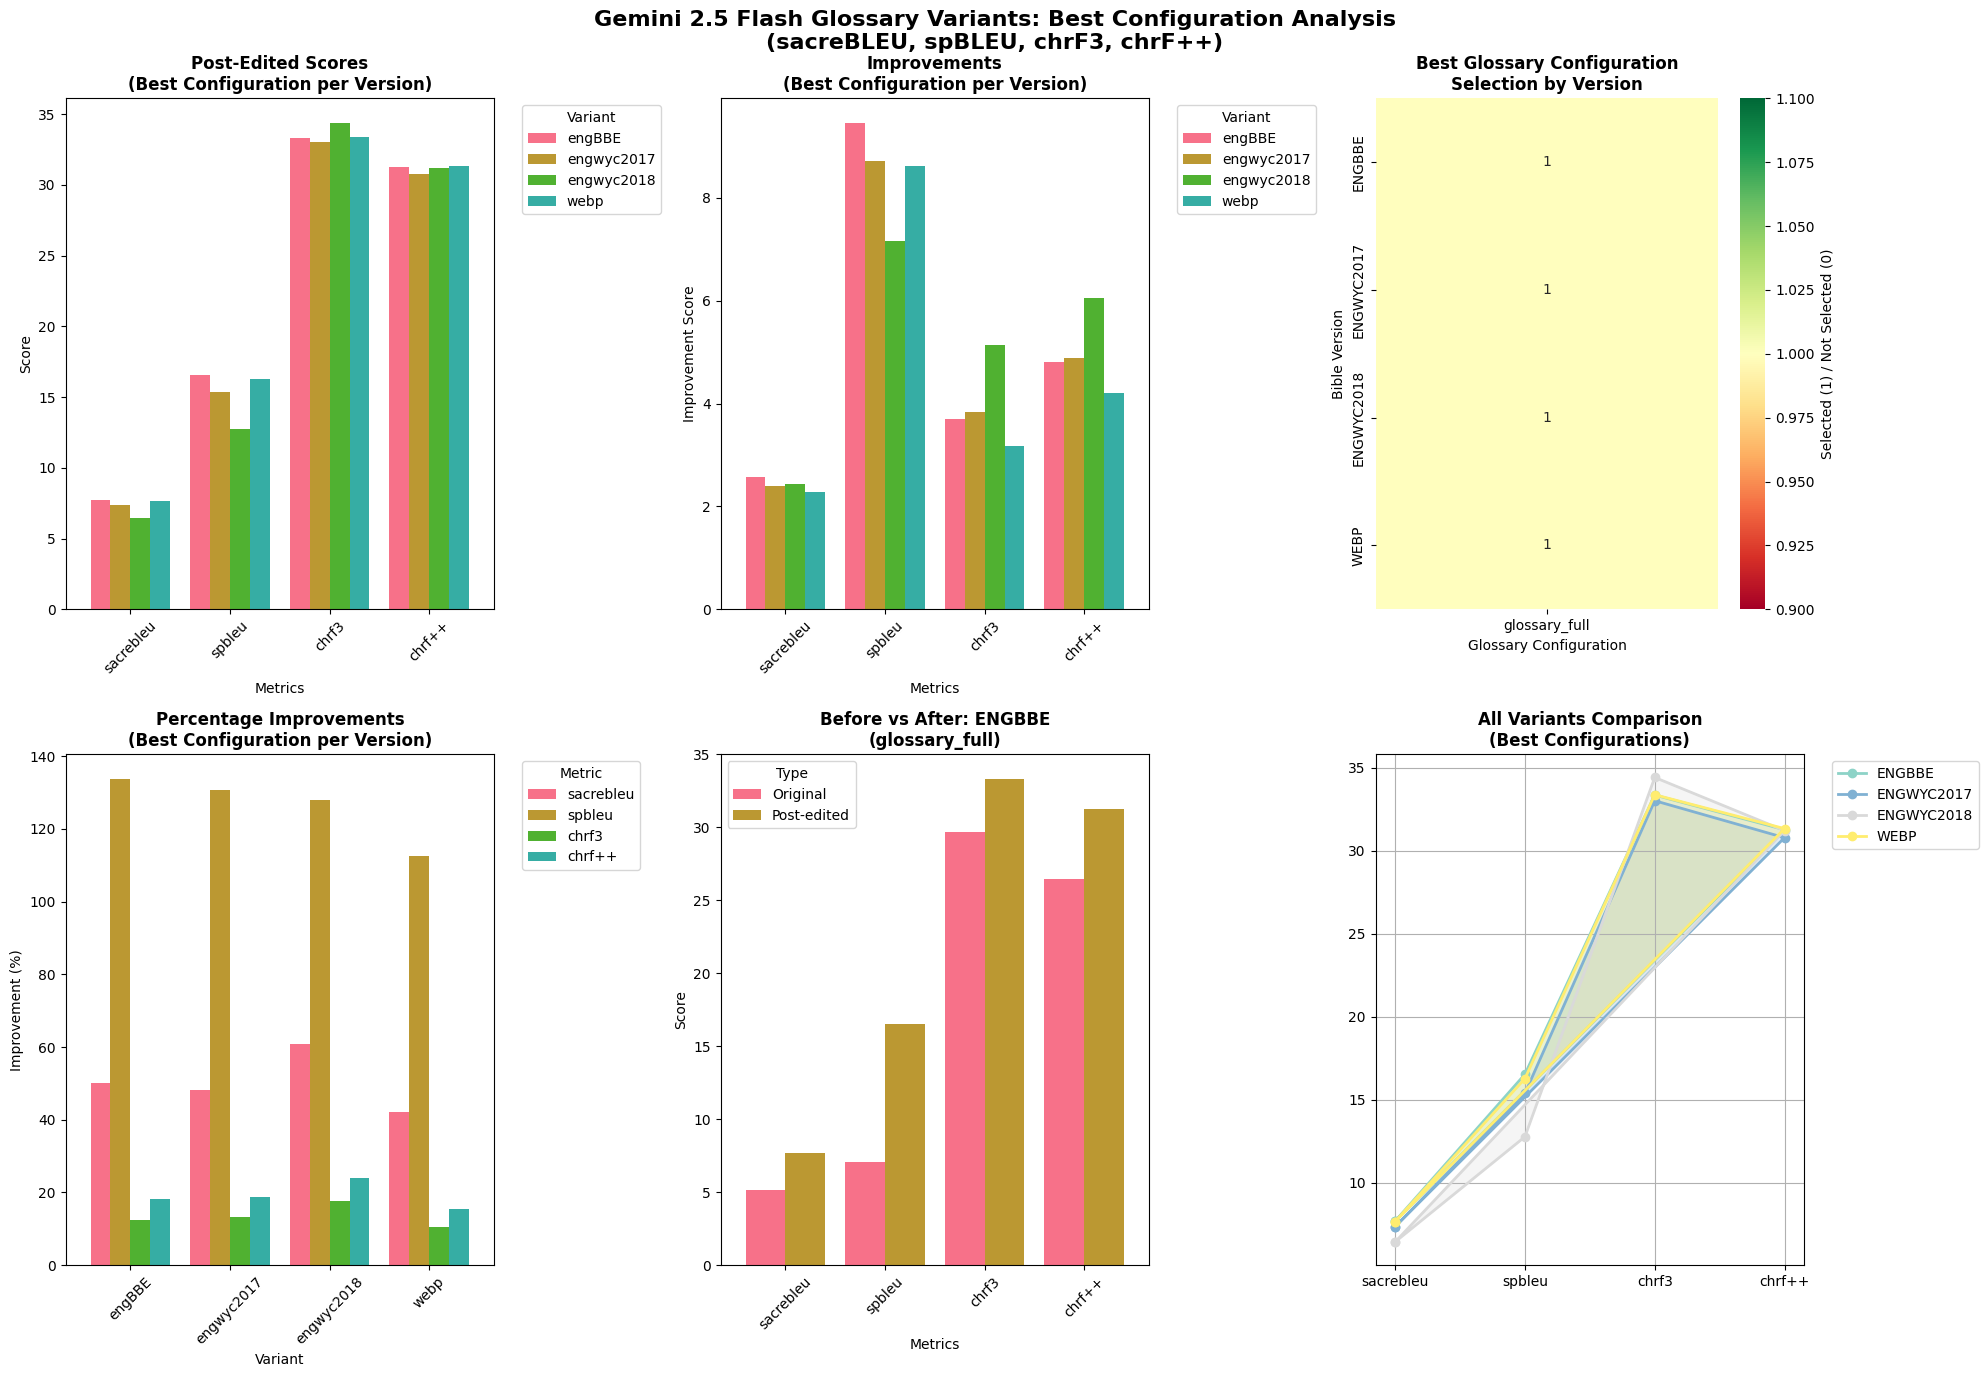

✅ Visualizations created successfully!

📊 Key Insights from Visualizations:
   • Chart 1-2: Direct performance comparison of best configs
   • Chart 3: Shows which glossary configs work best for each version
   • Chart 4: Percentage improvements highlight relative gains
   • Chart 5: Before/after for the overall winner
   • Chart 6: Radar plot shows strengths across all metrics


In [4]:
# Create comprehensive visualizations for BEST CONFIGURATIONS ONLY
print("\n" + "=" * 80)
print("STEP 3: VISUALIZATIONS (Best Configurations Only)")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('Gemini 2.5 Flash Glossary Variants: Best Configuration Analysis\n(sacreBLEU, spBLEU, chrF3, chrF++)', fontsize=16, fontweight='bold')

# 1. Post-edited scores (best configs only)
ax1 = axes[0, 0]
best_pe_plot_data = best_pe_df.set_index('variant')[metrics_to_analyze].T
best_pe_plot_data.plot(kind='bar', ax=ax1, width=0.8)
ax1.set_title('Post-Edited Scores\n(Best Configuration per Version)', fontweight='bold')
ax1.set_xlabel('Metrics')
ax1.set_ylabel('Score')
ax1.legend(title='Variant', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)

# 2. Improvements (best configs only)
ax2 = axes[0, 1]
best_imp_plot_data = best_imp_df.set_index('variant')[metrics_to_analyze].T
best_imp_plot_data.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Improvements\n(Best Configuration per Version)', fontweight='bold')
ax2.set_xlabel('Metrics')
ax2.set_ylabel('Improvement Score')
ax2.legend(title='Variant', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=45)

# 3. Glossary configuration selection heatmap
ax3 = axes[0, 2]
config_matrix = []
variants_ordered = sorted(best_configs_by_version.keys())
all_configs = sorted(list(set([config['glossary_config'] for config in best_configs_by_version.values()])))

for variant in variants_ordered:
    best_config = best_configs_by_version[variant]['glossary_config']
    row = [1 if config == best_config else 0 for config in all_configs]
    config_matrix.append(row)

config_df = pd.DataFrame(config_matrix, index=[v.upper() for v in variants_ordered], columns=all_configs)
sns.heatmap(config_df, annot=True, fmt='d', cmap='RdYlGn', ax=ax3, cbar_kws={'label': 'Selected (1) / Not Selected (0)'})
ax3.set_title('Best Glossary Configuration\nSelection by Version', fontweight='bold')
ax3.set_xlabel('Glossary Configuration')
ax3.set_ylabel('Bible Version')

# 4. Percentage improvements (best configs only)
ax4 = axes[1, 0]
pct_improvements_best = {}
for config in best_config_data:
    variant = config['variant']
    data = config['data']
    
    pct_improvements_best[variant] = {}
    for metric in metrics_to_analyze:
        orig = data['original_mt_metrics'][metric]
        imp = data['improvements'][metric]
        pct_improvements_best[variant][metric] = (imp / orig) * 100 if orig > 0 else 0

pct_imp_best_df = pd.DataFrame(pct_improvements_best).T
pct_imp_best_df.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_title('Percentage Improvements\n(Best Configuration per Version)', fontweight='bold')
ax4.set_xlabel('Variant')
ax4.set_ylabel('Improvement (%)')
ax4.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.tick_params(axis='x', rotation=45)

# 5. Before vs After comparison for overall winner
ax5 = axes[1, 1]
winner_variant = sorted_pe_rankings[0][0]
winner_config = best_configs_by_version[winner_variant]['glossary_config']
winner_data = None

for config in best_config_data:
    if config['variant'] == winner_variant:
        winner_data = config['data']
        break

if winner_data:
    comparison_data = pd.DataFrame({
        'Original': [winner_data['original_mt_metrics'][m] for m in metrics_to_analyze],
        'Post-edited': [winner_data['post_edited_metrics'][m] for m in metrics_to_analyze]
    }, index=metrics_to_analyze)
    
    comparison_data.plot(kind='bar', ax=ax5, width=0.8)
    ax5.set_title(f'Before vs After: {winner_variant.upper()}\n({winner_config})', fontweight='bold')
    ax5.set_xlabel('Metrics')
    ax5.set_ylabel('Score')
    ax5.legend(title='Type')
    ax5.tick_params(axis='x', rotation=45)

# 6. Radar plot for all variants (best configs)
ax6 = axes[1, 2]
angles = np.linspace(0, 2 * np.pi, len(metrics_to_analyze), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))  # Complete the circle

colors = plt.cm.Set3(np.linspace(0, 1, len(best_config_data)))

for i, config in enumerate(best_config_data):
    variant = config['variant']
    data = config['data']
    
    values = [data['post_edited_metrics'][m] for m in metrics_to_analyze]
    values += [values[0]]  # Complete the circle
    
    ax6.plot(angles, values, 'o-', linewidth=2, label=f"{variant.upper()}", color=colors[i])
    ax6.fill(angles, values, alpha=0.25, color=colors[i])

ax6.set_xticks(angles[:-1])
ax6.set_xticklabels(metrics_to_analyze)
ax6.set_title('All Variants Comparison\n(Best Configurations)', fontweight='bold')
ax6.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax6.grid(True)

plt.tight_layout()
plt.show()

print("✅ Visualizations created successfully!")
print("\n📊 Key Insights from Visualizations:")
print("   • Chart 1-2: Direct performance comparison of best configs")
print("   • Chart 3: Shows which glossary configs work best for each version")
print("   • Chart 4: Percentage improvements highlight relative gains") 
print("   • Chart 5: Before/after for the overall winner")
print("   • Chart 6: Radar plot shows strengths across all metrics")


In [5]:
# Final Summary and Recommendations
print("\n" + "=" * 80)
print("STEP 4: FINAL SUMMARY & RECOMMENDATIONS")
print("=" * 80)

print("\n🎯 EXECUTIVE SUMMARY:")
print("-" * 30)

# Best overall performer
best_overall = sorted_pe_rankings[0][0]
best_overall_rank = sorted_pe_rankings[0][1]
best_overall_config = best_configs_by_version[best_overall]['glossary_config']

print(f"🏆 BEST OVERALL PERFORMANCE: {best_overall.upper()}")
print(f"   Best configuration: {best_overall_config}")
print(f"   Average rank across metrics: {best_overall_rank:.2f}")

# Best improvement performer  
best_improvement = sorted_imp_rankings[0][0]
best_improvement_rank = sorted_imp_rankings[0][1]
best_improvement_config = best_configs_by_version[best_improvement]['glossary_config']

print(f"🚀 HIGHEST IMPROVEMENT: {best_improvement.upper()}")
print(f"   Best configuration: {best_improvement_config}")
print(f"   Average rank across metrics: {best_improvement_rank:.2f}")

# Check if they're the same
if best_overall == best_improvement:
    print(f"\n✅ CLEAR WINNER: {best_overall.upper()} excels in BOTH categories!")
    print(f"   Recommended setup: {best_overall.upper()} with {best_overall_config}")
else:
    print(f"\n📝 Different variants excel in different aspects:")
    print(f"   Choose based on your priority (performance vs improvement)")

print(f"\n📚 GLOSSARY CONFIGURATION ANALYSIS:")
print("-" * 45)

# Show what we learned about glossary configs
print("Best glossary configuration for each Bible version:")
for variant, info in best_configs_by_version.items():
    config = info['glossary_config']
    improvement = info['avg_improvement']
    print(f"  {variant.upper():12}: {config:15} (avg improv: +{improvement:.4f})")

# Glossary config patterns
config_counts = {}
for variant, info in best_configs_by_version.items():
    config = info['glossary_config']
    config_counts[config] = config_counts.get(config, 0) + 1

print(f"\nGlossary configuration success rate:")
for config, count in sorted(config_counts.items(), key=lambda x: x[1], reverse=True):
    percentage = (count / len(best_configs_by_version)) * 100
    print(f"  {config:15}: {count}/{len(best_configs_by_version)} versions ({percentage:5.1f}%)")

if len(set(config_counts.keys())) == 1:
    winning_config = list(config_counts.keys())[0]
    print(f"\n✅ UNANIMOUS WINNER: {winning_config}")
    print("   All Bible versions perform best with this configuration!")
else:
    most_common = max(config_counts.items(), key=lambda x: x[1])
    print(f"\n🏆 MOST SUCCESSFUL CONFIG: {most_common[0]} ({most_common[1]} versions)")

print(f"\n💡 KEY RECOMMENDATIONS:")
print("-" * 35)

print("1. BIBLE VERSION SELECTION:")
if best_overall == best_improvement:
    print(f"   → Use {best_overall.upper()} - best in both performance and improvement")
else:
    print(f"   → For max performance: {best_overall.upper()}")
    print(f"   → For max improvement: {best_improvement.upper()}")

print(f"\n2. GLOSSARY CONFIGURATION:")
if len(set(config_counts.keys())) == 1:
    print(f"   → Always use {list(config_counts.keys())[0]}")
else:
    most_common = max(config_counts.items(), key=lambda x: x[1])
    print(f"   → Generally use {most_common[0]} (works best for {most_common[1]}/{len(best_configs_by_version)} versions)")
    print(f"   → But check specific version recommendations above")

print(f"\n3. EXPECTED IMPROVEMENTS:")
winner_data = None
for config in best_config_data:
    if config['variant'] == best_overall:
        winner_data = config['data']
        break

if winner_data:
    print(f"   Using {best_overall.upper()} with {best_overall_config}:")
    for metric in metrics_to_analyze:
        orig = winner_data['original_mt_metrics'][metric]
        improved = winner_data['post_edited_metrics'][metric]  
        improvement = winner_data['improvements'][metric]
        pct = (improvement / orig) * 100
        print(f"     {metric:8}: {orig:6.2f} → {improved:6.2f} (+{improvement:5.2f}, {pct:5.1f}%)")

print(f"\n🔍 METHODOLOGY VALIDATION:")
print("-" * 35)
print("✅ This analysis used a 2-step approach:")
print("   1. Found the best glossary config for each Bible version")
print("   2. Compared only the best configurations against each other")
print("   This ensures fair comparison of each version's peak performance")

total_configs = len(results_data)
best_configs_used = len(best_config_data)
print(f"\n📊 Analysis scope: {best_configs_used}/{total_configs} configurations (best from each version)")
print(f"📈 Metrics analyzed: {', '.join(metrics_to_analyze)}")

print("\n" + "=" * 80)
print("🎉 ANALYSIS COMPLETE!")
print("Use the recommendations above to select your optimal glossary-based NMT setup.")
print("=" * 80)



STEP 4: FINAL SUMMARY & RECOMMENDATIONS

🎯 EXECUTIVE SUMMARY:
------------------------------
🏆 BEST OVERALL PERFORMANCE: ENGBBE
   Best configuration: glossary_full
   Average rank across metrics: 1.75
🚀 HIGHEST IMPROVEMENT: ENGBBE
   Best configuration: glossary_full
   Average rank across metrics: 2.00

✅ CLEAR WINNER: ENGBBE excels in BOTH categories!
   Recommended setup: ENGBBE with glossary_full

📚 GLOSSARY CONFIGURATION ANALYSIS:
---------------------------------------------
Best glossary configuration for each Bible version:
  ENGBBE      : glossary_full   (avg improv: +5.1335)
  ENGWYC2017  : glossary_full   (avg improv: +4.9565)
  ENGWYC2018  : glossary_full   (avg improv: +5.1976)
  WEBP        : glossary_full   (avg improv: +4.5678)

Glossary configuration success rate:
  glossary_full  : 4/4 versions (100.0%)

✅ UNANIMOUS WINNER: glossary_full
   All Bible versions perform best with this configuration!

💡 KEY RECOMMENDATIONS:
-----------------------------------
1. BIBLE V

In [6]:
# COMPARISON: Glossary vs Glossary_full
print("\n" + "=" * 80)
print("STEP 5: COMPARING GLOSSARY vs GLOSSARY_FULL METHODS")
print("=" * 80)

print("\n📊 Direct comparison between the two glossary post-editing methods:")
print("-" * 60)

# Create comparison for each variant
for variant in df_improvements['variant'].unique():
    print(f"\n{'=' * 60}")
    print(f"📖 {variant.upper()}")
    print(f"{'=' * 60}")
    
    variant_data = df_improvements[df_improvements['variant'] == variant]
    
    # Get data for both methods
    glossary_data = variant_data[variant_data['glossary_config'] == 'glossary']
    glossary_full_data = variant_data[variant_data['glossary_config'] == 'glossary_full']
    
    if len(glossary_data) > 0 and len(glossary_full_data) > 0:
        print(f"\n{'Method':<15} {'sacrebleu':>10} {'spbleu':>10} {'chrf3':>10} {'chrf++':>10} {'Avg':>10}")
        print("-" * 65)
        
        # Print glossary
        glossary_row = glossary_data.iloc[0]
        glossary_avg = glossary_data[metrics_to_analyze].mean().mean()
        print(f"{'glossary':<15} {glossary_row['sacrebleu']:>10.4f} {glossary_row['spbleu']:>10.4f} {glossary_row['chrf3']:>10.4f} {glossary_row['chrf++']:>10.4f} {glossary_avg:>10.4f}")
        
        # Print glossary_full
        glossary_full_row = glossary_full_data.iloc[0]
        glossary_full_avg = glossary_full_data[metrics_to_analyze].mean().mean()
        print(f"{'glossary_full':<15} {glossary_full_row['sacrebleu']:>10.4f} {glossary_full_row['spbleu']:>10.4f} {glossary_full_row['chrf3']:>10.4f} {glossary_full_row['chrf++']:>10.4f} {glossary_full_avg:>10.4f}")
        
        # Print difference (glossary_full - glossary)
        diff = glossary_full_data[metrics_to_analyze].iloc[0] - glossary_data[metrics_to_analyze].iloc[0]
        diff_avg = glossary_full_avg - glossary_avg
        print("-" * 65)
        print(f"{'Difference':<15} {diff['sacrebleu']:>+10.4f} {diff['spbleu']:>+10.4f} {diff['chrf3']:>+10.4f} {diff['chrf++']:>+10.4f} {diff_avg:>+10.4f}")
        
        # Winner
        if diff_avg > 0:
            winner = "glossary_full"
            improvement_pct = (diff_avg / glossary_avg) * 100
        else:
            winner = "glossary"
            improvement_pct = (-diff_avg / glossary_full_avg) * 100
        
        print(f"\n🏆 WINNER: {winner} (+{abs(diff_avg):.4f} avg improvement, {improvement_pct:.1f}% better)")

print("\n" + "=" * 80)
print("SUMMARY: Which method wins for each variant?")
print("=" * 80)

# Create summary table
winners = []
for variant in df_improvements['variant'].unique():
    variant_data = df_improvements[df_improvements['variant'] == variant]
    glossary_data = variant_data[variant_data['glossary_config'] == 'glossary']
    glossary_full_data = variant_data[variant_data['glossary_config'] == 'glossary_full']
    
    if len(glossary_data) > 0 and len(glossary_full_data) > 0:
        glossary_avg = glossary_data[metrics_to_analyze].mean().mean()
        glossary_full_avg = glossary_full_data[metrics_to_analyze].mean().mean()
        
        if glossary_full_avg > glossary_avg:
            winner = 'glossary_full'
            margin = glossary_full_avg - glossary_avg
            pct_better = (margin / glossary_avg) * 100
        else:
            winner = 'glossary'
            margin = glossary_avg - glossary_full_avg
            pct_better = (margin / glossary_full_avg) * 100
        
        winners.append({
            'variant': variant.upper(),
            'winner': winner,
            'margin': margin,
            'pct_better': pct_better
        })

winners_df = pd.DataFrame(winners)
print(f"\n{winners_df.to_string(index=False)}")

# Overall winner
winner_counts = winners_df['winner'].value_counts()
print(f"\n🏆 OVERALL WINNER: {winner_counts.idxmax()}")
print(f"   Wins {winner_counts.max()} out of {len(winners_df)} Bible versions ({winner_counts.max()/len(winners_df)*100:.1f}%)")

# Average margin of victory
avg_margin = winners_df['margin'].mean()
print(f"\n📊 Average margin of victory: {avg_margin:.4f} improvement points")



STEP 5: COMPARING GLOSSARY vs GLOSSARY_FULL METHODS

📊 Direct comparison between the two glossary post-editing methods:
------------------------------------------------------------

📖 ENGBBE

Method           sacrebleu     spbleu      chrf3     chrf++        Avg
-----------------------------------------------------------------
glossary            1.8991     7.1281     2.2697     3.3335     3.6576
glossary_full       2.5703     9.4637     3.6917     4.8084     5.1335
-----------------------------------------------------------------
Difference         +0.6712    +2.3356    +1.4220    +1.4749    +1.4759

🏆 WINNER: glossary_full (+1.4759 avg improvement, 40.4% better)

📖 ENGWYC2017

Method           sacrebleu     spbleu      chrf3     chrf++        Avg
-----------------------------------------------------------------
glossary            1.6483     6.3340     2.1696     3.2333     3.3463
glossary_full       2.3896     8.7179     3.8392     4.8794     4.9565
--------------------------------


STEP 6: VISUALIZING GLOSSARY vs GLOSSARY_FULL


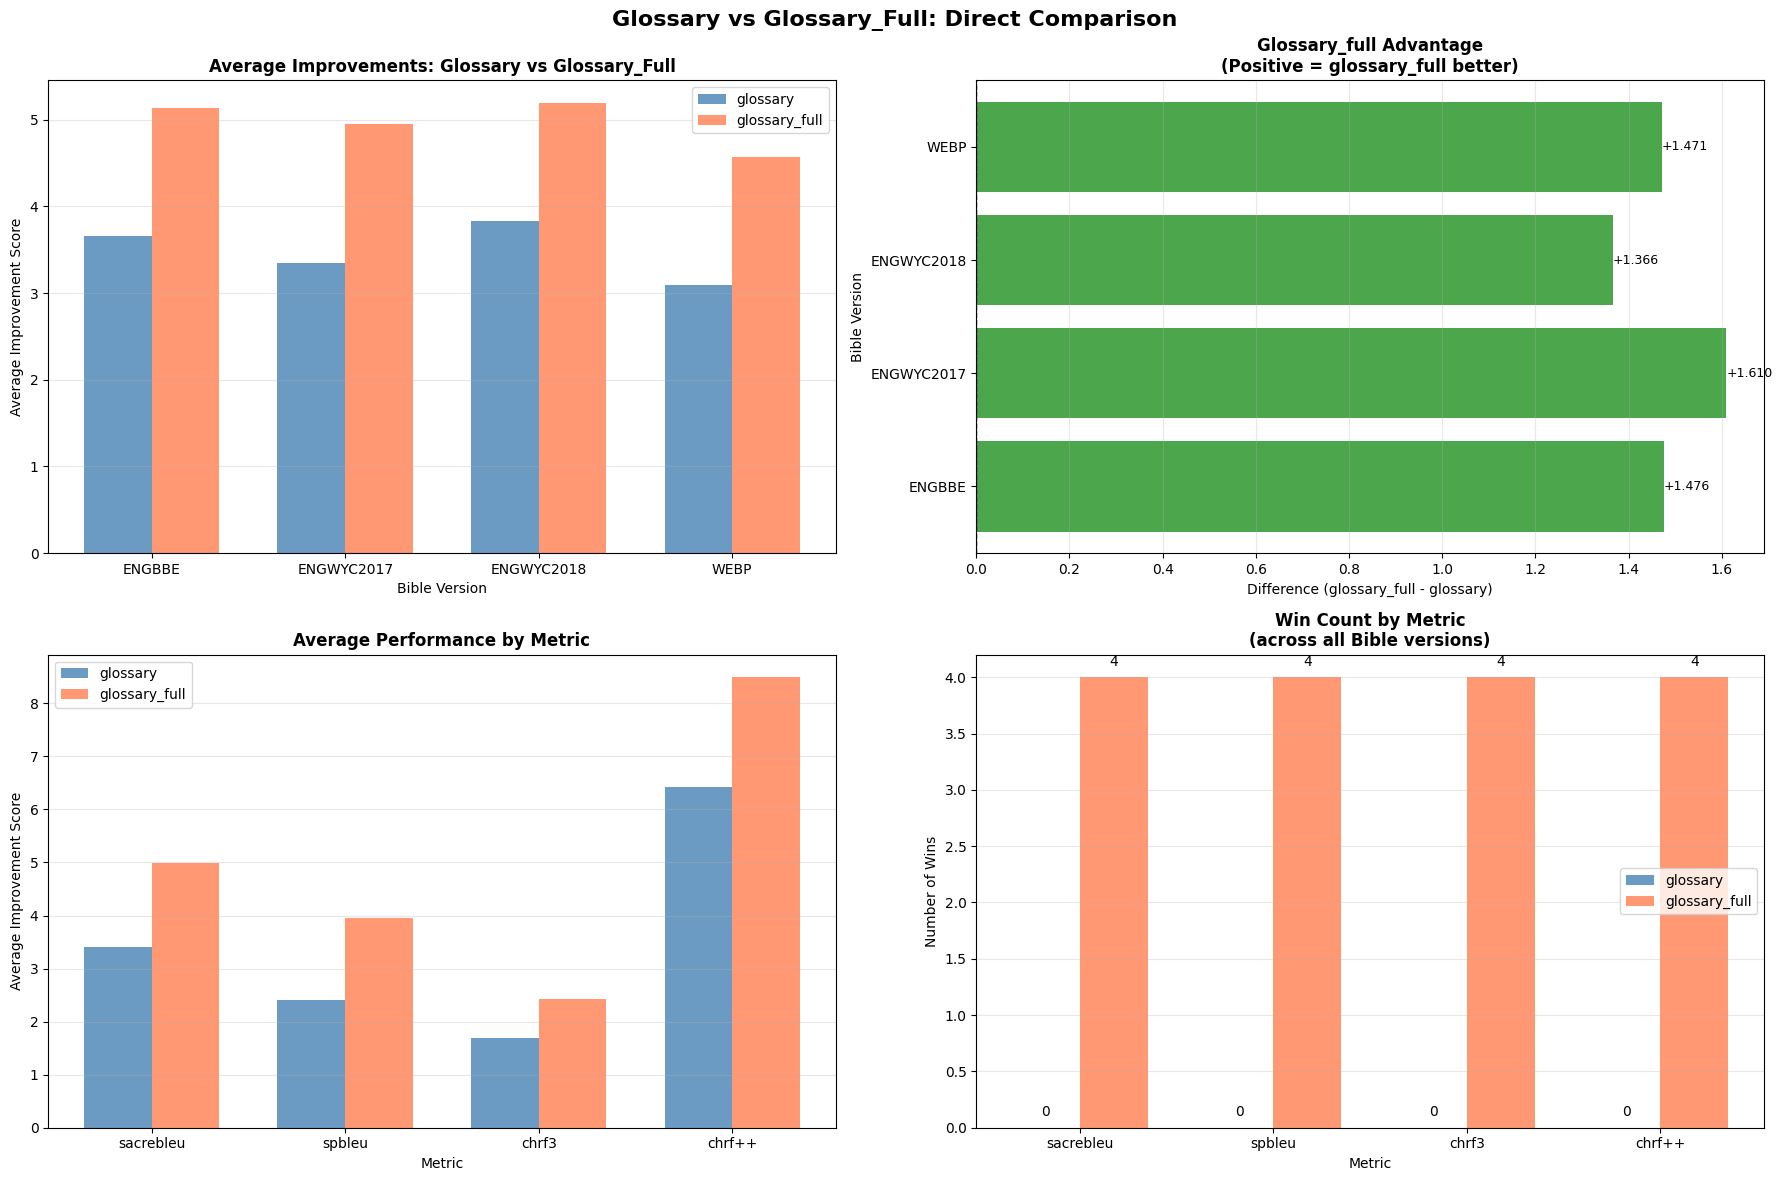

✅ Comparison visualizations created successfully!

📊 Key Insights:
   • Chart 1: Overall average improvements comparison
   • Chart 2: Direct differences showing which method wins per variant
   • Chart 3: Metric-specific performance comparison
   • Chart 4: Win counts across all variants per metric


In [7]:
# VISUALIZATION: Glossary vs Glossary_full Comparison
print("\n" + "=" * 80)
print("STEP 6: VISUALIZING GLOSSARY vs GLOSSARY_FULL")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Glossary vs Glossary_Full: Direct Comparison', fontsize=16, fontweight='bold')

# Prepare data for visualizations
comparison_data = []
for variant in df_improvements['variant'].unique():
    variant_data = df_improvements[df_improvements['variant'] == variant]
    
    for glossary_config in ['glossary', 'glossary_full']:
        config_data = variant_data[variant_data['glossary_config'] == glossary_config]
        if len(config_data) > 0:
            row = {'variant': variant, 'method': glossary_config}
            for metric in metrics_to_analyze:
                row[metric] = config_data.iloc[0][metric]
            comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)

# 1. Grouped bar chart: Improvements by method
ax1 = axes[0, 0]
comparison_pivot = comparison_df.pivot(index='variant', columns='method', values=metrics_to_analyze[0])
x = np.arange(len(comparison_pivot.index))
width = 0.35

for i, metric in enumerate(metrics_to_analyze):
    comparison_pivot = comparison_df.pivot(index='variant', columns='method', values=metric)
    if i == 0:
        ax1.bar(x - width/2, comparison_pivot['glossary'], width, label='glossary', alpha=0.8)
        ax1.bar(x + width/2, comparison_pivot['glossary_full'], width, label='glossary_full', alpha=0.8)

# Use average across all metrics
avg_by_variant_method = comparison_df.groupby(['variant', 'method'])[metrics_to_analyze].mean().mean(axis=1).unstack()
ax1.clear()
ax1.bar(x - width/2, avg_by_variant_method['glossary'], width, label='glossary', alpha=0.8, color='steelblue')
ax1.bar(x + width/2, avg_by_variant_method['glossary_full'], width, label='glossary_full', alpha=0.8, color='coral')

ax1.set_xlabel('Bible Version')
ax1.set_ylabel('Average Improvement Score')
ax1.set_title('Average Improvements: Glossary vs Glossary_Full', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([v.upper() for v in avg_by_variant_method.index])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Difference plot (glossary_full - glossary)
ax2 = axes[0, 1]
differences = []
for variant in comparison_df['variant'].unique():
    variant_comp = comparison_df[comparison_df['variant'] == variant]
    glossary_val = variant_comp[variant_comp['method'] == 'glossary'][metrics_to_analyze].mean(axis=1).values
    glossary_full_val = variant_comp[variant_comp['method'] == 'glossary_full'][metrics_to_analyze].mean(axis=1).values
    
    if len(glossary_val) > 0 and len(glossary_full_val) > 0:
        diff = glossary_full_val[0] - glossary_val[0]
        differences.append({'variant': variant, 'difference': diff})

diff_df = pd.DataFrame(differences)
colors = ['green' if d > 0 else 'red' for d in diff_df['difference']]

ax2.barh(diff_df['variant'].str.upper(), diff_df['difference'], color=colors, alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel('Difference (glossary_full - glossary)')
ax2.set_ylabel('Bible Version')
ax2.set_title('Glossary_full Advantage\n(Positive = glossary_full better)', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (_, row) in enumerate(diff_df.iterrows()):
    ax2.text(row['difference'], i, f"{row['difference']:+.3f}", 
             va='center', ha='left' if row['difference'] > 0 else 'right', fontsize=9)

# 3. Metric-by-metric comparison
ax3 = axes[1, 0]
metric_comparison = []
for metric in metrics_to_analyze:
    for method in ['glossary', 'glossary_full']:
        method_data = comparison_df[comparison_df['method'] == method]
        avg_val = method_data[metric].mean()
        metric_comparison.append({'metric': metric, 'method': method, 'avg_value': avg_val})

metric_comp_df = pd.DataFrame(metric_comparison)
metric_pivot = metric_comp_df.pivot(index='metric', columns='method', values='avg_value')

x_pos = np.arange(len(metrics_to_analyze))
ax3.bar(x_pos - width/2, metric_pivot['glossary'], width, label='glossary', alpha=0.8, color='steelblue')
ax3.bar(x_pos + width/2, metric_pivot['glossary_full'], width, label='glossary_full', alpha=0.8, color='coral')

ax3.set_xlabel('Metric')
ax3.set_ylabel('Average Improvement Score')
ax3.set_title('Average Performance by Metric', fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(metrics_to_analyze)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

# 4. Win rate visualization
ax4 = axes[1, 1]

# Calculate wins per metric
wins_by_metric = {}
for metric in metrics_to_analyze:
    wins_by_metric[metric] = {'glossary': 0, 'glossary_full': 0}
    
    for variant in comparison_df['variant'].unique():
        variant_comp = comparison_df[comparison_df['variant'] == variant]
        glossary_val = variant_comp[variant_comp['method'] == 'glossary'][metric].values
        glossary_full_val = variant_comp[variant_comp['method'] == 'glossary_full'][metric].values
        
        if len(glossary_val) > 0 and len(glossary_full_val) > 0:
            if glossary_full_val[0] > glossary_val[0]:
                wins_by_metric[metric]['glossary_full'] += 1
            else:
                wins_by_metric[metric]['glossary'] += 1

wins_df = pd.DataFrame(wins_by_metric).T
x_pos = np.arange(len(metrics_to_analyze))

ax4.bar(x_pos - width/2, wins_df['glossary'], width, label='glossary', alpha=0.8, color='steelblue')
ax4.bar(x_pos + width/2, wins_df['glossary_full'], width, label='glossary_full', alpha=0.8, color='coral')

ax4.set_xlabel('Metric')
ax4.set_ylabel('Number of Wins')
ax4.set_title('Win Count by Metric\n(across all Bible versions)', fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics_to_analyze)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, metric in enumerate(metrics_to_analyze):
    ax4.text(i - width/2, wins_df.loc[metric, 'glossary'] + 0.1, 
             str(int(wins_df.loc[metric, 'glossary'])), ha='center', fontsize=10)
    ax4.text(i + width/2, wins_df.loc[metric, 'glossary_full'] + 0.1, 
             str(int(wins_df.loc[metric, 'glossary_full'])), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("✅ Comparison visualizations created successfully!")
print("\n📊 Key Insights:")
print("   • Chart 1: Overall average improvements comparison")
print("   • Chart 2: Direct differences showing which method wins per variant")
print("   • Chart 3: Metric-specific performance comparison")
print("   • Chart 4: Win counts across all variants per metric")


In [8]:
# CORRELATION ANALYSIS: Perplexity vs Improvements
print("\n" + "=" * 80)
print("STEP 7: CORRELATION WITH PERPLEXITY SCORES")
print("=" * 80)

# Load perplexity scores
perplexity_file = "/data/projects/punim0478/setiawand/bible-nmt/perplexity_scoring/bible_perplexity_scores_filtered.csv"

try:
    perplexity_df = pd.read_csv(perplexity_file)
    
    print(f"\n📊 Loaded perplexity scores from: {perplexity_file}")
    print(f"   Total rows: {len(perplexity_df)}")
    
    # Map variant names to perplexity scores
    variant_mapping = {
        'engBBE': 'engBBE',
        'engwyc2017': 'engwyc2017', 
        'engwyc2018': 'engwyc2018',
        'webp': 'engwebp'
    }
    
    print(f"\n🔍 Filtering perplexity scores for our variants:")
    print("-" * 60)
    
    # Filter perplexity data for our variants
    filtered_perplexity = []
    for our_variant, perplexity_variant in variant_mapping.items():
        match = perplexity_df[perplexity_df['english_version'] == perplexity_variant]
        if len(match) > 0:
            perplexity_score = match.iloc[0]['perplexity_score']
            filtered_perplexity.append({
                'variant': our_variant,
                'perplexity_score': perplexity_score
            })
            print(f"  ✅ {our_variant:12} ({perplexity_variant:12}) → Perplexity: {perplexity_score:.2f}")
        else:
            print(f"  ❌ {our_variant:12} ({perplexity_variant:12}) → NOT FOUND in perplexity data")
    
    perplexity_filtered_df = pd.DataFrame(filtered_perplexity)
    
    # Merge with our best improvement data
    correlation_df = best_imp_df.merge(perplexity_filtered_df, on='variant', how='inner')
    
    print(f"\n📋 Combined data for correlation analysis:")
    print(correlation_df[['variant', 'glossary_config', 'sacrebleu', 'spbleu', 'chrf3', 'chrf++', 'perplexity_score']])
    
    # Calculate correlations
    print(f"\n📈 CORRELATION ANALYSIS:")
    print("-" * 60)
    print("Correlation between perplexity score and improvement metrics:\n")
    
    for metric in metrics_to_analyze:
        corr = correlation_df['perplexity_score'].corr(correlation_df[metric])
        print(f"  {metric:10}: {corr:7.4f}")
        
        # Interpret the correlation
        if abs(corr) < 0.3:
            strength = "weak"
        elif abs(corr) < 0.7:
            strength = "moderate"
        else:
            strength = "strong"
        
        direction = "positive" if corr > 0 else "negative"
        print(f"             ({strength} {direction} correlation)")
        
        if corr > 0:
            print(f"             → Higher perplexity → Higher improvement")
        else:
            print(f"             → Higher perplexity → Lower improvement")
        print()
    
    # Calculate average improvement correlation
    avg_improvement = correlation_df[metrics_to_analyze].mean(axis=1)
    correlation_df['avg_improvement'] = avg_improvement
    corr_avg = correlation_df['perplexity_score'].corr(correlation_df['avg_improvement'])
    
    print(f"  {'Avg Improv':10}: {corr_avg:7.4f}")
    if abs(corr_avg) < 0.3:
        strength = "weak"
    elif abs(corr_avg) < 0.7:
        strength = "moderate"
    else:
        strength = "strong"
    direction = "positive" if corr_avg > 0 else "negative"
    print(f"             ({strength} {direction} correlation)")
    print(f"             → This is the overall trend across all metrics")
    
    print(f"\n💡 INTERPRETATION:")
    print("-" * 60)
    
    if corr_avg > 0.5:
        print("✅ POSITIVE CORRELATION: Higher perplexity scores are associated with")
        print("   higher improvement scores. This suggests that Bible versions that")
        print("   are more 'different' or complex compared to the target language")
        print("   benefit more from glossary-based post-editing.")
    elif corr_avg < -0.5:
        print("✅ NEGATIVE CORRELATION: Lower perplexity scores are associated with")
        print("   higher improvement scores. This suggests that Bible versions that")
        print("   are more 'similar' to the target language benefit more from")
        print("   glossary-based post-editing.")
    else:
        print("⚠️  WEAK/NO CORRELATION: Perplexity score does not show a strong")
        print("   relationship with improvement scores. This suggests that other")
        print("   factors (e.g., translation style, vocabulary, glossary effectiveness)")
        print("   may be more important for post-editing improvement than perplexity alone.")
    
    print(f"\n⚠️  NOTE: With only {len(correlation_df)} data points, statistical")
    print("   significance is limited. More Bible versions would be needed for")
    print("   stronger conclusions.")

except FileNotFoundError:
    print(f"\n❌ Perplexity file not found: {perplexity_file}")
    print("   Skipping correlation analysis.")

print("\n" + "=" * 80)



STEP 7: CORRELATION WITH PERPLEXITY SCORES

📊 Loaded perplexity scores from: /data/projects/punim0478/setiawand/bible-nmt/perplexity_scoring/bible_perplexity_scores_filtered.csv
   Total rows: 30

🔍 Filtering perplexity scores for our variants:
------------------------------------------------------------
  ✅ engBBE       (engBBE      ) → Perplexity: 97.34
  ✅ engwyc2017   (engwyc2017  ) → Perplexity: 100.77
  ✅ engwyc2018   (engwyc2018  ) → Perplexity: 189.31
  ✅ webp         (engwebp     ) → Perplexity: 109.32

📋 Combined data for correlation analysis:
      variant glossary_config  sacrebleu  spbleu   chrf3  chrf++  \
0      engBBE   glossary_full     2.5703  9.4637  3.6917  4.8084   
1  engwyc2017   glossary_full     2.3896  8.7179  3.8392  4.8794   
2  engwyc2018   glossary_full     2.4379  7.1696  5.1364  6.0465   
3        webp   glossary_full     2.2752  8.6146  3.1699  4.2114   

   perplexity_score  
0           97.3408  
1          100.7690  
2          189.3110  
3         